In [297]:
import pandas as pd
#LOADING THE DATASET
df=pd.read_csv("spambase_csv.csv")

In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [299]:
df.head(5)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [300]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [301]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [303]:
#FEATURES
x=df.drop(["class","capital_run_length_average","capital_run_length_longest","capital_run_length_total"],axis=1)
y=df["class"]

In [304]:
#Normalizing or standardizing the features
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x,y)

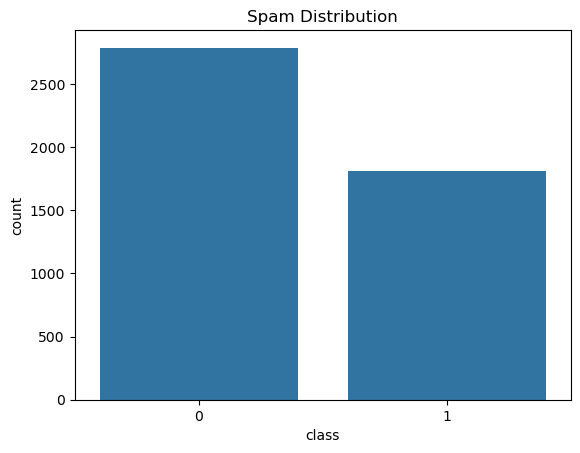

In [305]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="class",data=df)
plt.title("Spam Distribution")
plt.show()

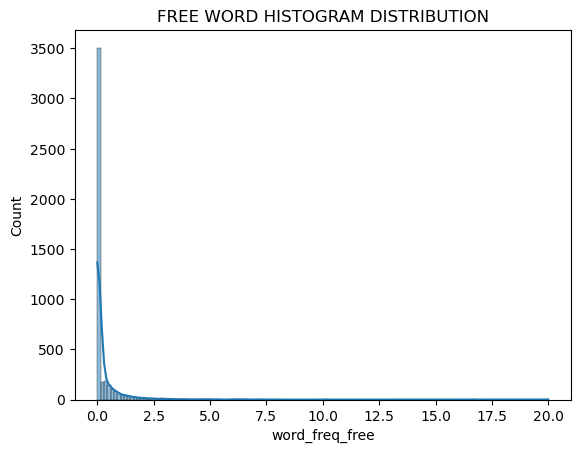

In [306]:
sns.histplot(df["word_freq_free"],kde="true")
plt.title("FREE WORD HISTOGRAM DISTRIBUTION")
plt.show()

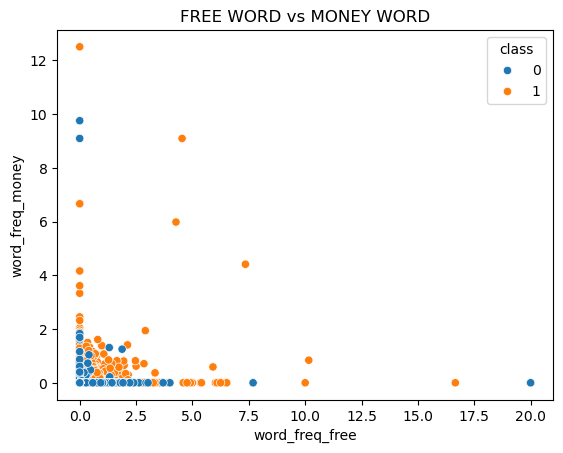

In [307]:
sns.scatterplot(data=df,x="word_freq_free",y="word_freq_money",hue="class")
plt.title("FREE WORD vs MONEY WORD")
plt.show()

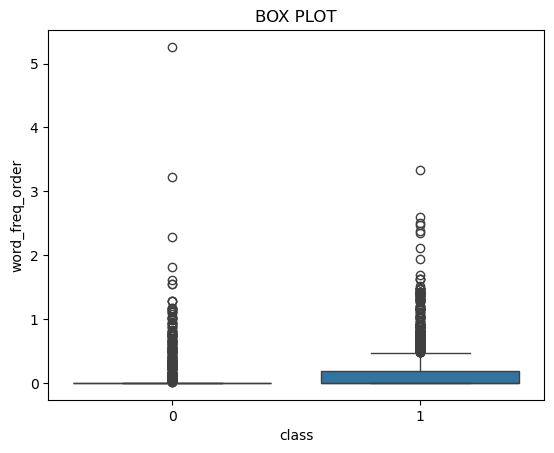

In [308]:
sns.boxplot(x="class",y="word_freq_order",data=df)
plt.title("BOX PLOT")
plt.show()

In [309]:
#splitting data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [310]:
#class balance
import numpy as np
np.bincount(y_train)

array([2257, 1423])

Confusion Matrix: Gaussian
[[384 147]
 [ 24 366]]


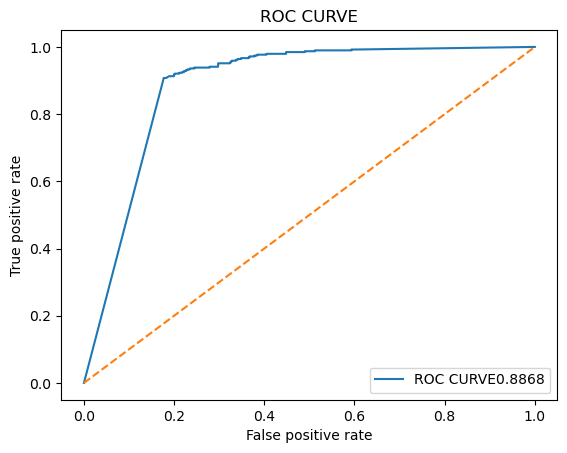

Confusion Matrix: Bernoulli
[[506  25]
 [ 64 326]]


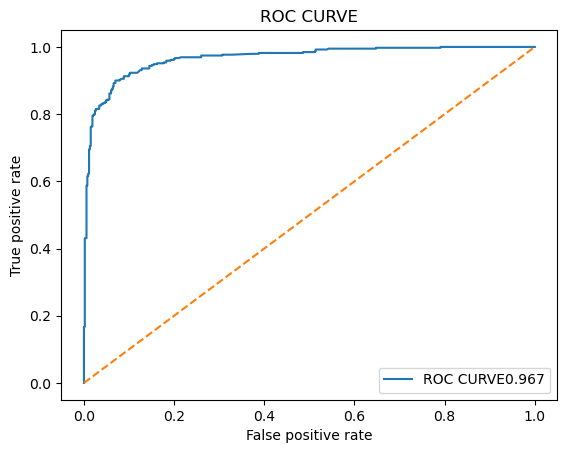

Confusion Matrix: Multinomial
[[515  16]
 [ 95 295]]


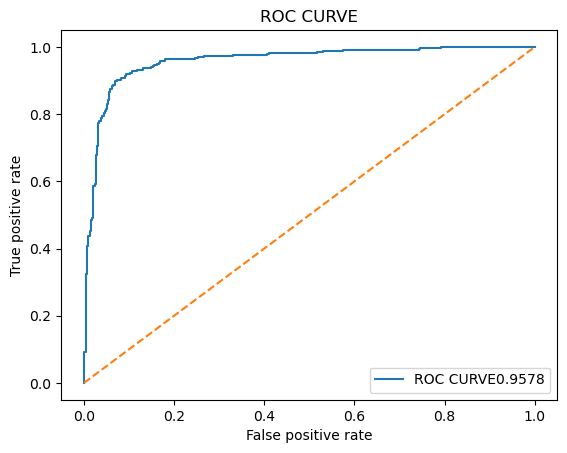

,Gaussian,Bernoulli,Multinomial
accuracy,0.814332,0.903366,0.879479
precision,0.713450,0.928775,0.948553
recall,0.938462,0.835897,0.756410
f1,0.810631,0.879892,0.841655


In [311]:
#Training the models
#Naıve Bayes (Gaussian, Multinomial, Bernoulli)

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_curve,auc
result={}

mm=MinMaxScaler()
x_train_mm=mm.fit_transform(x_train)
x_test_mm=mm.transform(x_test)

for name,model in {("Gaussian",GaussianNB()),("Multinomial",MultinomialNB()),("Bernoulli",BernoulliNB())}:
    if name=="Multinomial":
        train,test=x_train_mm,x_test_mm
    else:
        train,test=x_train,x_test
    model.fit(train,y_train)
    y_pred=model.predict(test)

    #Accuracy, Precision, Recall, F1-score
    result[name]={"accuracy": accuracy_score(y_test, y_pred),"precision": precision_score(y_test, y_pred),"recall": recall_score(y_test, y_pred),"f1": f1_score(y_test, y_pred)}
   
    #Confusion Matrix
    print("Confusion Matrix:",name)
    cm=confusion_matrix(y_test, y_pred)
    print(cm)
    
    #roc curve
    y_prob= model.predict_proba(test)[:,1]
    fpr,tpr,_=roc_curve(y_test,y_prob)
    roc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label="ROC CURVE" + str(round(roc,4)))
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC CURVE")
    plt.legend()
    plt.show()

pd.DataFrame(result)


1


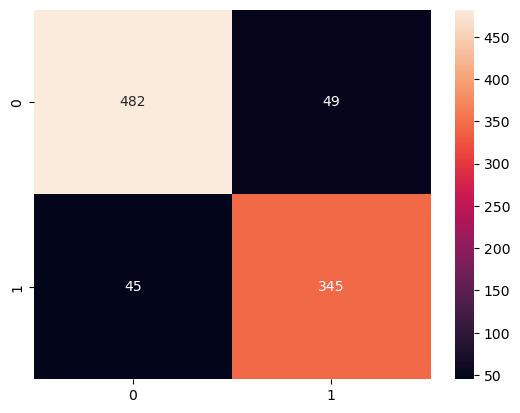

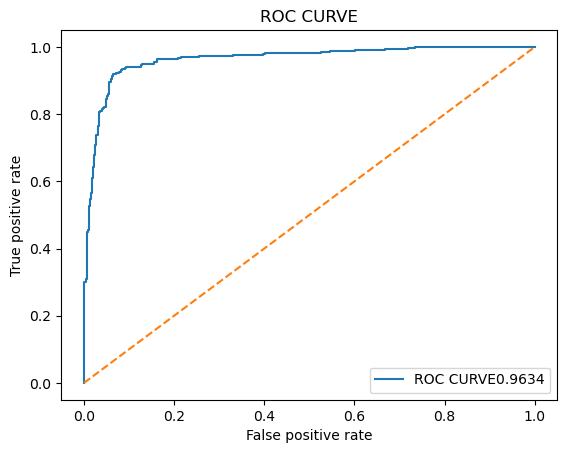

3


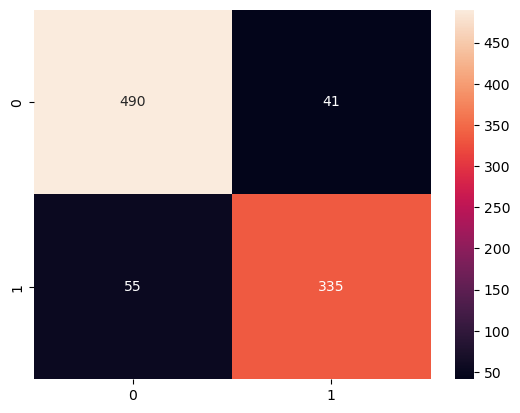

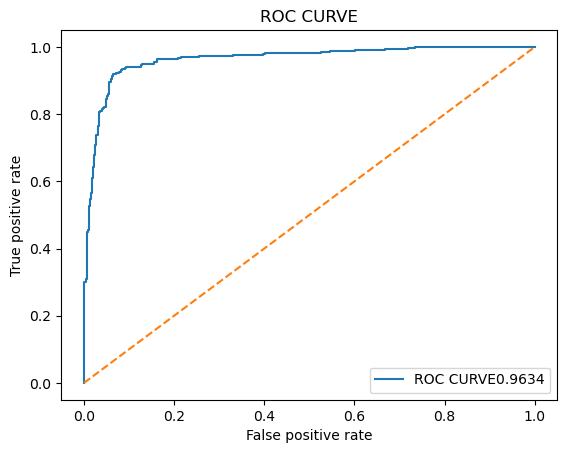

5


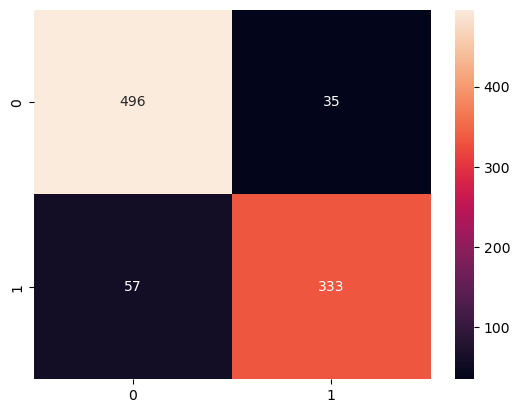

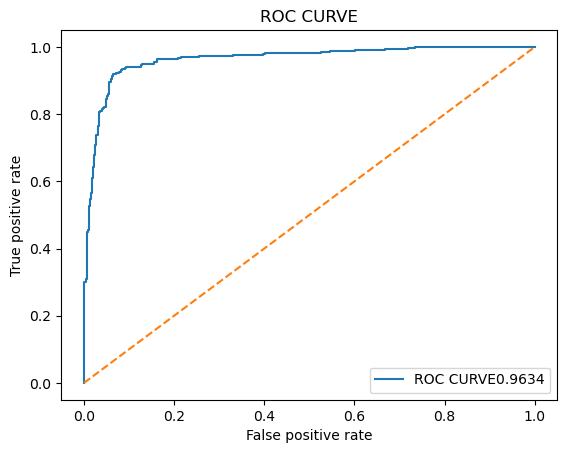

7


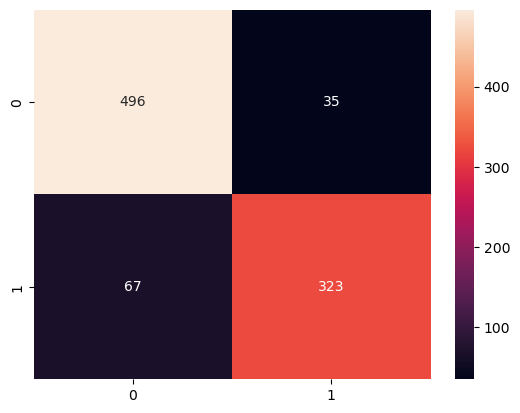

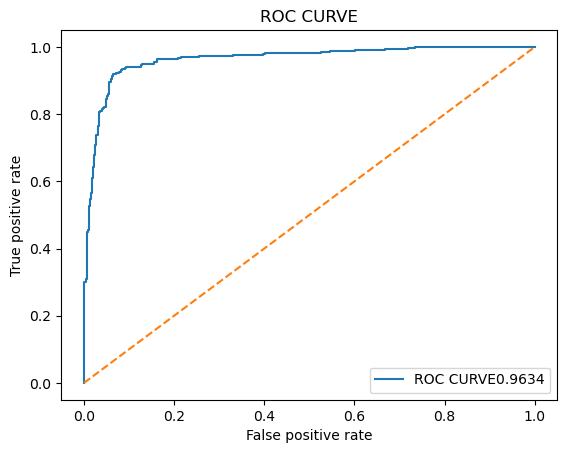

,1,3,5,7
accuracy,0.897937,0.895765,0.900109,0.889251
precision,0.875635,0.890957,0.904891,0.902235
recall,0.884615,0.858974,0.853846,0.828205
f1,0.880102,0.874674,0.878628,0.863636


In [312]:
from sklearn.neighbors import KNeighborsClassifier
result1={}
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)

    result1[k]={"accuracy": accuracy_score(y_test, y_pred),"precision": precision_score(y_test, y_pred),"recall": recall_score(y_test, y_pred),"f1": f1_score(y_test, y_pred)}

    print(k)
    cm=confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.show()
    
    #roc curve
    y_prob= model.predict_proba(x_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,y_prob)
    roc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label="ROC CURVE" + str(round(roc,4)))
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC CURVE")
    plt.legend()
    plt.show()
pd.DataFrame(result1)


kd_tree


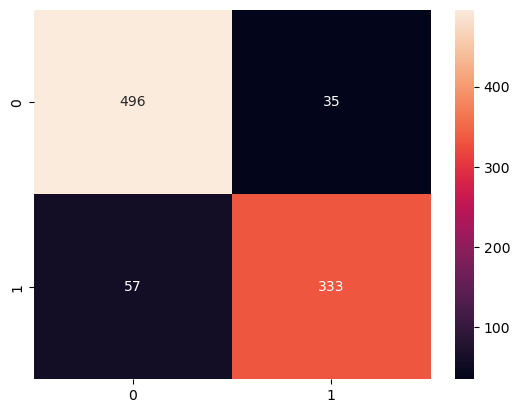

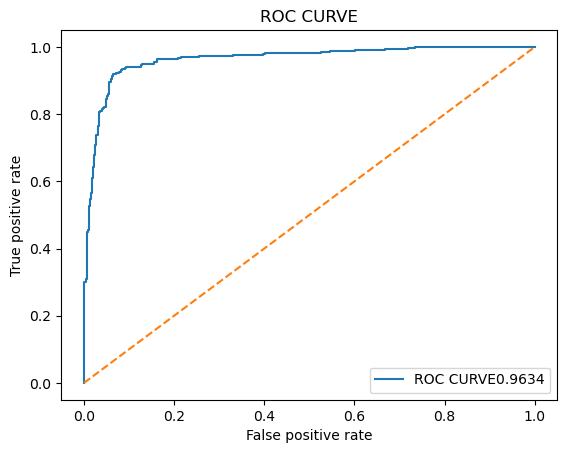

ball_tree


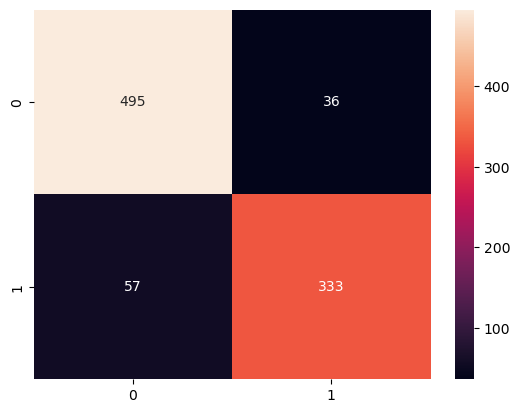

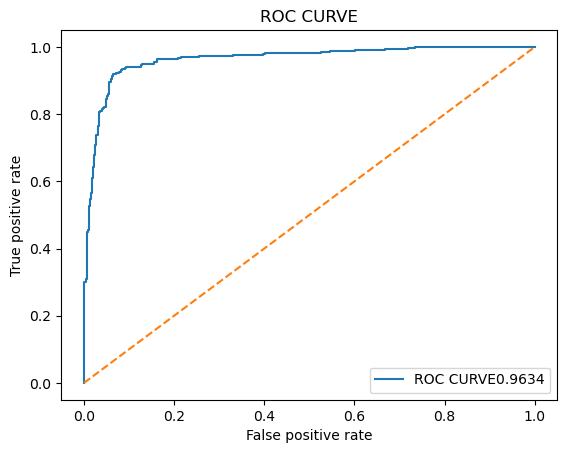

,kd_tree,ball_tree
accuracy,0.900109,0.899023
precision,0.904891,0.902439
recall,0.853846,0.853846
f1,0.878628,0.877470
Training time(s),0.001812,0.002603


In [313]:
import time
result2={}
for algo in ["kd_tree", "ball_tree"]:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    start=time.time()
    knn.fit(x_train, y_train)
    end=time.time()
    training_time=end-start
    y_pred = knn.predict(x_test)

    
    result2[algo]={"accuracy": accuracy_score(y_test, y_pred),"precision": precision_score(y_test, y_pred),"recall": recall_score(y_test, y_pred),"f1": f1_score(y_test, y_pred),"Training time(s)":training_time}
    print(algo)
    cm=confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.show()
    
    #roc curve
    y_prob= model.predict_proba(x_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,y_prob)
    roc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label="ROC CURVE" + str(round(roc,4)))
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC CURVE")
    plt.legend()
    plt.show()
pd.DataFrame(result2)



Linear


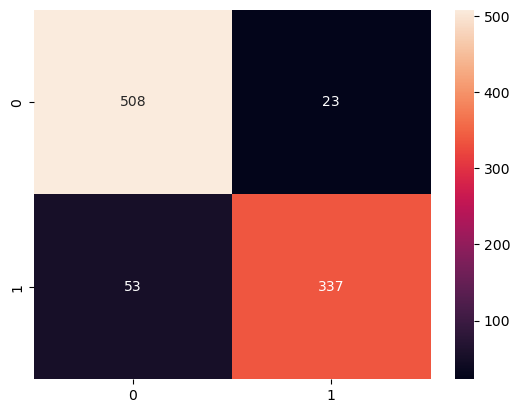

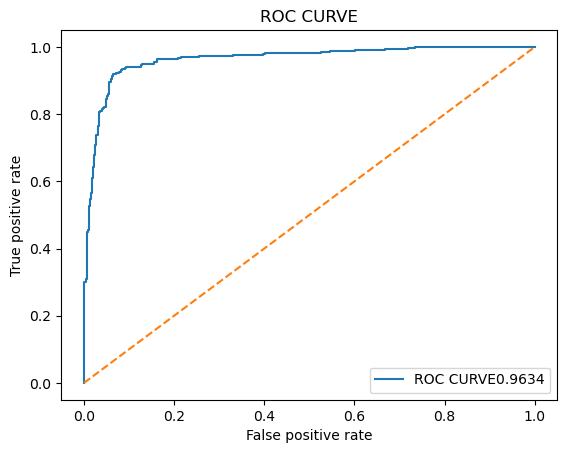

Polynomial


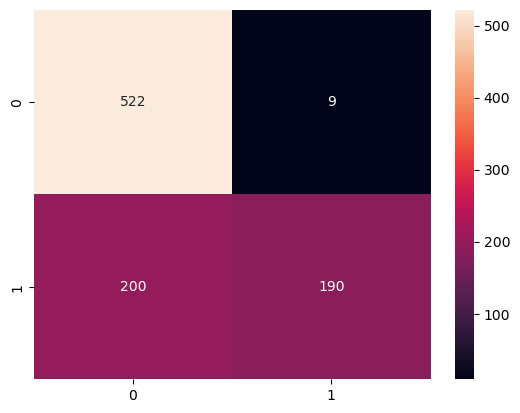

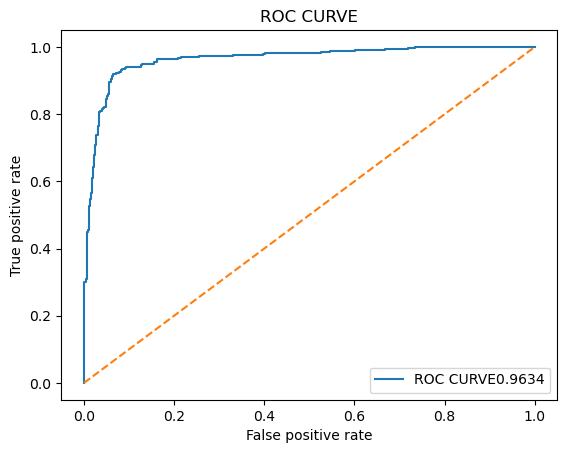

RBF


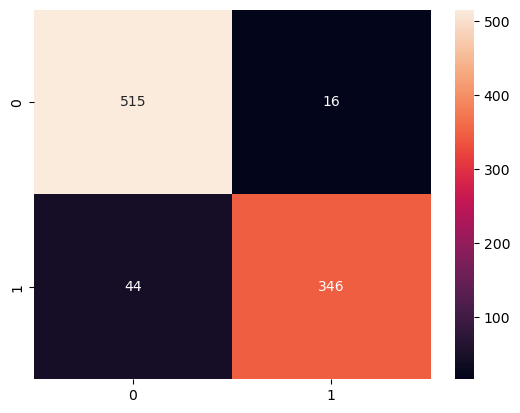

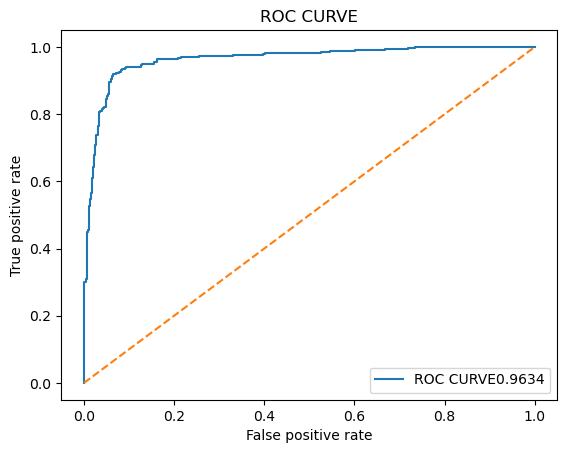

Sigmoid


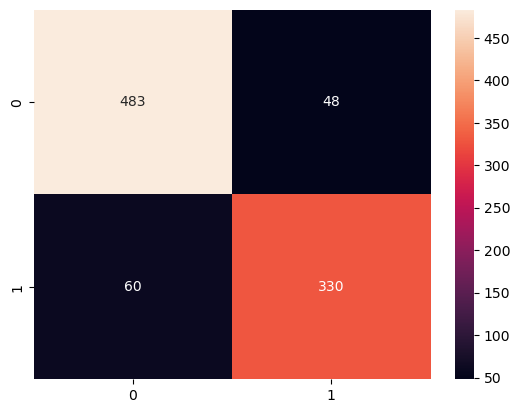

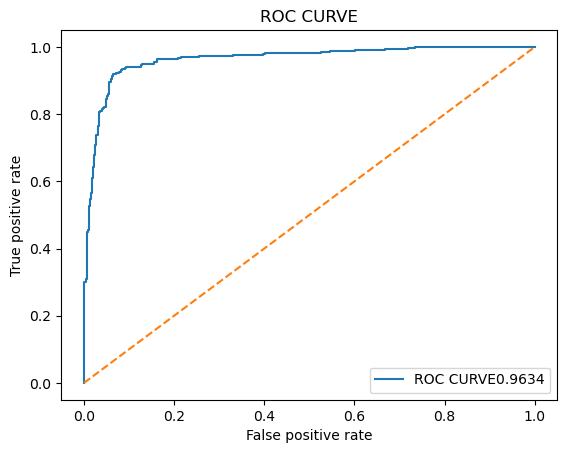

,Linear,Polynomial,RBF,Sigmoid
hyperparameter,"SVC(C=1, kernel='linear', probability=True)","SVC(C=1, kernel='poly', probability=True)","SVC(C=1, probability=True)","SVC(C=1, kernel='sigmoid', probability=True)"
accuracy,0.917481,0.773073,0.934853,0.882736
precision,0.936111,0.954774,0.955801,0.873016
recall,0.864103,0.487179,0.887179,0.846154
f1,0.898667,0.645161,0.920213,0.859375
Training time(s),0.839557,0.890524,0.666736,0.526577


In [314]:
from sklearn.svm import SVC
result3={}
kernels = {
    "Linear": SVC(kernel="linear", C=1, probability=True),
    "Polynomial": SVC(kernel="poly", C=1, degree=3, probability=True),
    "RBF": SVC(kernel="rbf", C=1, gamma="scale", probability=True),
    "Sigmoid": SVC(kernel="sigmoid", C=1, probability=True)
}

for name, svm in kernels.items():
    start=time.time()
    svm.fit(x_train, y_train)
    end=time.time()
    training_time=end-start
    y_pred = svm.predict(x_test)

    result3[name]={"hyperparameter":kernels[name],"accuracy": accuracy_score(y_test, y_pred),"precision": precision_score(y_test, y_pred),"recall": recall_score(y_test, y_pred),"f1": f1_score(y_test, y_pred),"Training time(s)":training_time}

    print(name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.show()

    #roc curve
    y_prob= model.predict_proba(x_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,y_prob)
    roc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label="ROC CURVE" + str(round(roc,4)))
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC CURVE")
    plt.legend()
    plt.show()
pd.DataFrame(result3)


In [315]:
#K-Fold Cross-Validation(K = 5)
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import pandas as pd
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", C=1)
}
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model,x_scaled, y,cv=kf,scoring="accuracy")
    cv_results[name] = scores

cv_table = pd.DataFrame({"Fold 1": [cv_results["Naive Bayes"][0],cv_results["KNN"][0],cv_results["SVM"][0]],
    "Fold 2": [cv_results["Naive Bayes"][1],cv_results["KNN"][1],cv_results["SVM"][1]],
    "Fold 3": [cv_results["Naive Bayes"][2],cv_results["KNN"][2],cv_results["SVM"][2]],
    "Fold 4": [cv_results["Naive Bayes"][3],cv_results["KNN"][3],cv_results["SVM"][3]],
    "Fold 5": [cv_results["Naive Bayes"][4],cv_results["KNN"][4],cv_results["SVM"][4]],
    "Average": [cv_results["Naive Bayes"].mean(),cv_results["KNN"].mean(),cv_results["SVM"].mean()]
},
index=["Naive Bayes", "KNN", "SVM"])
print(cv_table.T)


         Naive Bayes       KNN       SVM
Fold 1      0.814332  0.872964  0.934853
Fold 2      0.801087  0.870652  0.932609
Fold 3      0.792391  0.895652  0.918478
Fold 4      0.819565  0.892391  0.933696
Fold 5      0.822826  0.885870  0.926087
Average     0.810040  0.883506  0.929145
